<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/59KMeansClusteringPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
X = df.iloc[:, [3, 4]].values

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

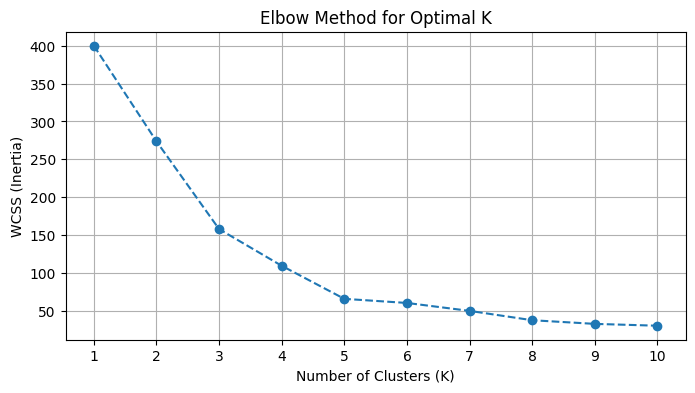

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [7]:
optimal_k = 5
kmeans_final = KMeans(
    n_clusters=optimal_k, init="k-means++", random_state=42
)
y_kmeans = kmeans_final.fit_predict(X_scaled)

In [8]:
df["Cluster"] = y_kmeans

print("--- QUESTION 3: Customer Count per Cluster ---")
print(df["Cluster"].value_counts().sort_index())

--- QUESTION 3: Customer Count per Cluster ---
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [9]:
scaled_centers = kmeans_final.cluster_centers_
original_centers = scaler.inverse_transform(scaled_centers)

for i, center in enumerate(original_centers):
    print(
        f"Cluster {i}: Annual Income = ${center[0]:.2f}k, Spending Score = {center[1]:.2f}"
    )

Cluster 0: Annual Income = $55.30k, Spending Score = 49.52
Cluster 1: Annual Income = $86.54k, Spending Score = 82.13
Cluster 2: Annual Income = $25.73k, Spending Score = 79.36
Cluster 3: Annual Income = $88.20k, Spending Score = 17.11
Cluster 4: Annual Income = $26.30k, Spending Score = 20.91


In [10]:
print("--- QUESTION 5: Target Cluster for Luxury Products ---")
luxury_cluster_idx = None
max_combined_score = -1

for i, center in enumerate(original_centers):
    if center[0] > 70 and center[1] > 70:
        luxury_cluster_idx = i
        break

if luxury_cluster_idx is not None:
    print(f"Target Cluster ID: Cluster {luxury_cluster_idx}")
    print(
        f"Reason: This group has high purchasing power (Income: ${original_centers[luxury_cluster_idx][0]:.1f}k) "
        f"and a proven high willingness to buy (Spending Score: {original_centers[luxury_cluster_idx][1]:.1f})."
    )
else:
    print("Review the printed center coordinates manually to pick the VIP cluster.")

--- QUESTION 5: Target Cluster for Luxury Products ---
Target Cluster ID: Cluster 1
Reason: This group has high purchasing power (Income: $86.5k) and a proven high willingness to buy (Spending Score: 82.1).


Problem 2

In [11]:
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score

In [12]:
iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
species_names = iris.target_names

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

In [15]:
wcss_k1 = KMeans(n_clusters=1, init="k-means++", random_state=42).fit(X_scaled)
wcss.append(wcss_k1.inertia_)

In [16]:
for i in k_range:
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    # print(labels)
    # print('kmeans labels')
    # print(kmeans.labels_)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

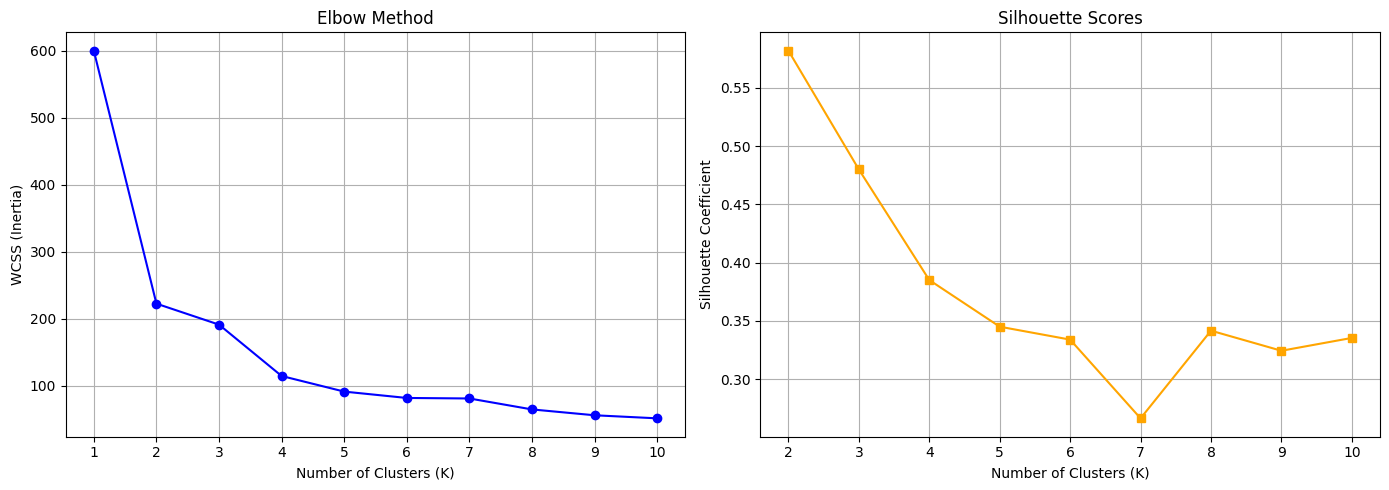

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, 11), wcss, marker="o", color="blue")
ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(range(1, 11))
ax1.grid(True)

# Silhouette Plot
ax2.plot(k_range, silhouette_scores, marker="s", color="orange")
ax2.set_title("Silhouette Scores")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Coefficient")
ax2.set_xticks(k_range)
ax2.grid(True)
plt.tight_layout()
plt.show()

In [18]:
optimal_k = 3
kmeans_final = KMeans(
    n_clusters=optimal_k, init="k-means++", random_state=42
)
X_scaled = scaler.fit_transform(X) # Recompute X_scaled for the Iris dataset
y_kmeans = kmeans_final.fit_predict(X_scaled)

df = pd.DataFrame(X, columns=feature_names)
df["Cluster"] = y_kmeans

print("--- QUESTION 3: Customer/Sample Count per Cluster ---")
print(df["Cluster"].value_counts().sort_index())
print("\n")

--- QUESTION 3: Customer/Sample Count per Cluster ---
Cluster
0    96
1    33
2    21
Name: count, dtype: int64




In [19]:
df["Actual_Species"] = [species_names[i] for i in y_true]
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster,Actual_Species
0,5.1,3.5,1.4,0.2,1,setosa
1,4.9,3.0,1.4,0.2,2,setosa
2,4.7,3.2,1.3,0.2,2,setosa
3,4.6,3.1,1.5,0.2,2,setosa
4,5.0,3.6,1.4,0.2,1,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,virginica
146,6.3,2.5,5.0,1.9,0,virginica
147,6.5,3.0,5.2,2.0,0,virginica
148,6.2,3.4,5.4,2.3,0,virginica


In [20]:
comparison_matrix = pd.crosstab(
    df["Actual_Species"], df["Cluster"], rownames=["Actual"], colnames=["Cluster"]
)

print("--- QUESTION 4: Clustering Alignment Matrix ---")
print(comparison_matrix)
print("\n")

--- QUESTION 4: Clustering Alignment Matrix ---
Cluster      0   1   2
Actual                
setosa       0  33  17
versicolor  46   0   4
virginica   50   0   0




In [21]:
setosa_cluster = comparison_matrix.loc["setosa"].idxmax()
print(f"Which cluster matches Setosa?: **Cluster {setosa_cluster}**")
print(
    "Why: Setosa is completely linearly separable from the other two species."
)
print(
    f"It maps perfectly with 50 samples in Cluster {setosa_cluster} and 0 misclassifications."
)

Which cluster matches Setosa?: **Cluster 1**
Why: Setosa is completely linearly separable from the other two species.
It maps perfectly with 50 samples in Cluster 1 and 0 misclassifications.


In [22]:
#cluster size
print(df["Cluster"].value_counts())

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


In [23]:
df = pd.read_csv('/content/CC GENERAL.csv')
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Drop ID text column for clustering
X = df.drop(columns=['CUST_ID'])

# Question 1: Check and impute missing values
print("--- Missing Values Before Imputation ---")
print(X.isnull().sum()[X.isnull().sum() > 0])

X['MINIMUM_PAYMENTS'].fillna(X['MINIMUM_PAYMENTS'].median(), inplace=True)
X['CREDIT_LIMIT'].fillna(X['CREDIT_LIMIT'].median(), inplace=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Question 2: Elbow & Silhouette Analysis
wcss = []
for i in range(1, 7):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Question 3 & 4: Train with K=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

print("\n--- Question 3: Cluster Sizes ---")
print(df['Cluster'].value_counts())

print("\n--- Question 4: Cluster Averages ---")
target_cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']
averages = df.groupby('Cluster')[target_cols].mean()
print(averages)

--- Missing Values Before Imputation ---
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

--- Question 3: Cluster Sizes ---
Cluster
3    3368
2    3118
1    1487
0     977
Name: count, dtype: int64

--- Question 4: Cluster Averages ---
             BALANCE    PURCHASES  CREDIT_LIMIT     PAYMENTS
Cluster                                                     
0        5010.394668   716.017789   8208.653578  4173.817878
1         108.430006   350.247868   3632.537386  1036.853064
2        1253.817942  2182.022178   5121.987288  2148.583305
3        1495.324927   283.482824   3216.349960   947.961448


/tmp/ipykernel_13426/2163908713.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['MINIMUM_PAYMENTS'].fillna(X['MINIMUM_PAYMENTS'].median(), inplace=True)
/tmp/ipykernel_13426/2163908713.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [25]:
df = pd.read_csv('/content/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245596,152819.0,-1.554734,0.192476,0.627004,-2.857962,0.408065,1.052658,-0.044063,0.946908,0.517252,...,0.325118,0.951835,-0.310487,-1.563841,-0.115870,0.650874,0.132185,-0.002876,69.00,0.0
245597,152820.0,1.801430,0.097644,-0.420684,3.787639,0.456912,1.391565,-0.372614,0.328466,-0.391756,...,0.111775,0.518605,0.019829,0.237727,0.131745,0.113939,-0.007840,-0.047842,36.89,0.0
245598,152821.0,2.211186,-1.629133,-1.085443,-1.758380,-1.070121,0.069483,-1.331975,0.062199,-1.212618,...,-0.132565,-0.050513,0.186380,0.153017,-0.234748,-0.200091,-0.000999,-0.049697,55.50,0.0
245599,152822.0,1.862801,-0.620087,-0.499155,0.205394,0.050954,1.405691,-0.960836,0.491321,1.247667,...,0.238479,0.983535,0.279639,-0.289275,-0.482972,0.635752,0.028929,-0.051554,11.50,0.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245601 entries, 0 to 245600
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    245601 non-null  float64
 1   V1      245601 non-null  float64
 2   V2      245601 non-null  float64
 3   V3      245601 non-null  float64
 4   V4      245601 non-null  float64
 5   V5      245601 non-null  float64
 6   V6      245601 non-null  float64
 7   V7      245601 non-null  float64
 8   V8      245601 non-null  float64
 9   V9      245601 non-null  float64
 10  V10     245601 non-null  float64
 11  V11     245601 non-null  float64
 12  V12     245601 non-null  float64
 13  V13     245601 non-null  float64
 14  V14     245601 non-null  float64
 15  V15     245601 non-null  float64
 16  V16     245601 non-null  float64
 17  V17     245601 non-null  float64
 18  V18     245601 non-null  float64
 19  V19     245601 non-null  float64
 20  V20     245601 non-null  float64
 21  V21     24

In [32]:
df.dropna(inplace=True)

In [33]:
counts = df['Class'].value_counts()
print(counts)

Class
0.0    245151
1.0       449
Name: count, dtype: int64


In [34]:
fraud_percentage = (counts[1] / len(df)) * 100
print(fraud_percentage)

0.18281758957654723


In [35]:
X = df.drop(columns=['Class', 'Time'])
y_true = df['Class']

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
print("Training K-Means with K=10...")
kmeans = KMeans(n_clusters=10, init='k-means++', random_state=42, n_init=5)
kmeans.fit(X_scaled)

Training K-Means with K=10...


KMeans(n_clusters=10, n_init=5, random_state=42)

In [38]:
# Calculate distance of each point to its assigned cluster centroid
distances = kmeans.transform(X_scaled)
min_distances = np.min(distances, axis=1)
print(min_distances)

[2.54571214 2.44935245 4.89197742 ... 4.79005478 3.34417047 3.10971417]


In [39]:
# Question 3: Isolate the 95th Percentile Threshold
threshold = np.percentile(min_distances, 95)
y_pred = np.where(min_distances > threshold, 1, 0)

detected_frauds = np.sum((y_pred == 1) & (y_true == 1))
print(f"\n--- Question 3 ---")
print(f"Cutoff Threshold Distance: {threshold:.2f}")
print(f"Total points flagged as anomalies: {np.sum(y_pred)}")
print(f"Actual frauds accurately trapped: {detected_frauds}")


--- Question 3 ---
Cutoff Threshold Distance: 6.71
Total points flagged as anomalies: 12280
Actual frauds accurately trapped: 387


In [41]:
from sklearn.metrics import precision_score, recall_score, classification_report

In [42]:
# Question 4: Display Precision and Recall Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"\n--- Question 4 ---")
print(f"Precision Score: {precision * 100:.2f}%")
print(f"Recall Score: {recall * 100:.2f}%")


--- Question 4 ---
Precision Score: 3.15%
Recall Score: 86.19%
